# CHGNet Training Pipeline

This notebook loads VASP simulation data, prepares a dataset, initializes CHGNet, and trains the model.

In [46]:
# Section 1: Import Required Libraries
from chgnet.data.dataset import StructureData
from pymatgen.io.vasp import Vasprun
import glob
import os
from chgnet.model import CHGNet
from chgnet.trainer import Trainer

In [47]:
# Section 2: Load VASP Data and Prepare Dataset
structures = []
energies = []
forces = []

vasp_files = glob.glob("50-hzo-*/*/vasprun.xml")
print(f"Found {len(vasp_files)} VASP runs")

for vr_file in vasp_files:
    try:
        vr = Vasprun(vr_file)
        structure = vr.final_structure
        energy = vr.final_energy / len(structure)
        force = vr.ionic_steps[-1]["forces"]

        structures.append(structure)
        energies.append(energy)
        forces.append(force)

        print(f"Loaded {vr_file}")
    except Exception as e:
        print(f"Skipping {vr_file}: {e}")

dataset = StructureData(
    structures=structures,
    energies=energies,
    forces=forces
)
print("Dataset ready!")

Found 235 VASP runs
Loaded 50-hzo-a\1\vasprun.xml
Loaded 50-hzo-a\2\vasprun.xml
Loaded 50-hzo-a\3\vasprun.xml
Loaded 50-hzo-a\1\vasprun.xml
Loaded 50-hzo-a\2\vasprun.xml
Loaded 50-hzo-a\3\vasprun.xml
Loaded 50-hzo-a\4\vasprun.xml
Loaded 50-hzo-a\5\vasprun.xml
Loaded 50-hzo-a\6\vasprun.xml
Loaded 50-hzo-a\4\vasprun.xml
Loaded 50-hzo-a\5\vasprun.xml
Loaded 50-hzo-a\6\vasprun.xml
Loaded 50-hzo-c\1\vasprun.xml
Loaded 50-hzo-c\2\vasprun.xml
Loaded 50-hzo-c\3\vasprun.xml
Loaded 50-hzo-c\1\vasprun.xml
Loaded 50-hzo-c\2\vasprun.xml
Loaded 50-hzo-c\3\vasprun.xml
Loaded 50-hzo-c\4\vasprun.xml
Loaded 50-hzo-c\5\vasprun.xml
Loaded 50-hzo-c\6\vasprun.xml
Loaded 50-hzo-c\4\vasprun.xml
Loaded 50-hzo-c\5\vasprun.xml
Loaded 50-hzo-c\6\vasprun.xml
Loaded 50-hzo-cc\1\vasprun.xml
Loaded 50-hzo-cc\10\vasprun.xml
Loaded 50-hzo-cc\11\vasprun.xml
Loaded 50-hzo-cc\1\vasprun.xml
Loaded 50-hzo-cc\10\vasprun.xml
Loaded 50-hzo-cc\11\vasprun.xml
Loaded 50-hzo-cc\12\vasprun.xml
Loaded 50-hzo-cc\13\vasprun.xml
Loaded

In [48]:
# Section 3: Initialize and Load Pretrained CHGNet Model
model = CHGNet.load()  # load pretrained model

CHGNet initialized with 400,438 parameters


In [49]:
# Section 4: Train CHGNet Model
import chgnet.data.dataset
print(dir(chgnet.data.dataset))
# After running this cell, check the output for available dataset classes and update the next cell accordingly.

['CIFData', 'CrystalGraph', 'CrystalGraphConverter', 'DataLoader', 'Dataset', 'GraphData', 'Sequence', 'Structure', 'StructureData', 'StructureJsonData', 'SubsetRandomSampler', 'TYPE_CHECKING', 'Tensor', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'annotations', 'collate_graphs', 'datatype', 'functools', 'get_loader', 'get_train_val_test_loader', 'np', 'os', 'random', 'torch', 'utils', 'warnings']


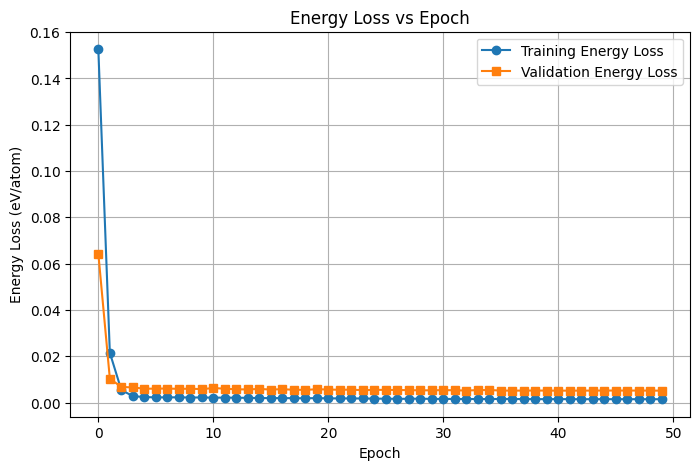

In [70]:
# Plot Training and Validation Energy Loss vs Epoch
import matplotlib.pyplot as plt

history = trainer.training_history

plt.figure(figsize=(8,5))
plt.plot(history['e']['train'], label='Training Energy Loss', marker='o')
plt.plot(history['e']['val'], label='Validation Energy Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Energy Loss (eV/atom)')
plt.title('Energy Loss vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

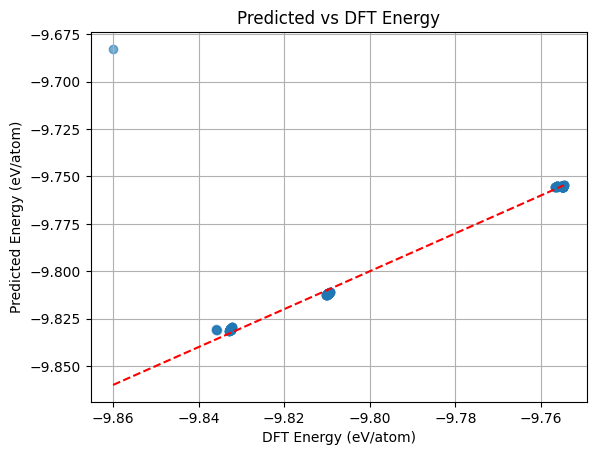

In [69]:
# Plot Predicted vs DFT Energy Scatter
predicted = []
true = []

for structure, energy in zip(dataset.structures, dataset.energies):
    pred = model.predict_structure(structure)
    # If pred is a dict or array, extract scalar value
    if isinstance(pred, dict):
        # Try common keys
        if 'energy' in pred:
            pred_val = pred['energy']
        elif 'e' in pred:
            pred_val = pred['e']
        else:
            pred_val = list(pred.values())[0]  # fallback: first value
    elif hasattr(pred, 'item'):
        pred_val = pred.item()
    elif hasattr(pred, '__float__'):
        pred_val = float(pred)
    else:
        pred_val = pred
    predicted.append(pred_val)
    true.append(energy)

import matplotlib.pyplot as plt

plt.scatter(true, predicted, alpha=0.6)
plt.plot([min(true), max(true)], [min(true), max(true)], 'r--')  # y=x reference
plt.xlabel('DFT Energy (eV/atom)')
plt.ylabel('Predicted Energy (eV/atom)')
plt.title('Predicted vs DFT Energy')
plt.grid(True)
plt.show()

In [54]:
# Plot Forces MAE vs Epoch (if available)
if hasattr(trainer, 'forces_mae'):
    plt.figure(figsize=(8,5))
    plt.plot(trainer.forces_mae, label='Forces MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.title('Forces MAE vs Epoch')
    plt.legend()
    plt.show()

In [55]:
# Inspect Trainer attributes for loss history
print(dir(trainer))
# After running, look for any attribute related to loss or history and let me know the name.

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_init_keys', '_train', '_validate', 'best_model', 'criterion', 'device', 'epochs', 'get_best_model', 'load', 'model', 'move_to', 'optimizer', 'print_freq', 'save', 'save_checkpoint', 'scheduler', 'scheduler_type', 'starting_epoch', 'targets', 'train', 'trainer_args', 'training_history']


In [59]:
# Manually split dataset into training and validation sets
import random

indices = list(range(len(dataset)))
random.seed(42)
random.shuffle(indices)

split = int(0.8 * len(indices))
train_idx, val_idx = indices[:split], indices[split:]

train_data = [dataset[i] for i in train_idx]
val_data = [dataset[i] for i in val_idx]

print(f"Train size: {len(train_data)}, Val size: {len(val_data)}")

Train size: 185, Val size: 47


In [60]:
from chgnet.model import CHGNet
from chgnet.trainer import Trainer

model = CHGNet.load()  # pretrained universal model

CHGNet initialized with 400,438 parameters


In [64]:
from torch.utils.data import DataLoader
from chgnet.data.dataset import get_train_val_test_loader

# Prepare data loaders using CHGNet utility (handles graph batching)
train_loader, val_loader = get_train_val_test_loader(
    dataset, batch_size=8, train_ratio=0.8, val_ratio=0.2, return_test=False
)

trainer = Trainer(
    model=model,
    targets="ef",          # energy + forces
    learning_rate=1e-4,
)

trainer.train(
    train_loader=train_loader,
    val_loader=val_loader,
    # epochs already configured in trainer initialization if needed
)


Begin Training: using cpu device
training targets: ef
Epoch: [0][1/24]	Time (2.101)  Data (0.004)  Loss 0.2054 (0.2054)  MAEs:  e 0.451 (0.451)  f 0.034 (0.034)  
Epoch: [0][1/24]	Time (2.101)  Data (0.004)  Loss 0.2054 (0.2054)  MAEs:  e 0.451 (0.451)  f 0.034 (0.034)  
*   e_MAE (0.064) 	f_MAE (0.030) 	
*   e_MAE (0.064) 	f_MAE (0.030) 	
Epoch: [1][1/24]	Time (0.679)  Data (0.003)  Loss 0.0060 (0.0060)  MAEs:  e 0.062 (0.062)  f 0.030 (0.030)  
Epoch: [1][1/24]	Time (0.679)  Data (0.003)  Loss 0.0060 (0.0060)  MAEs:  e 0.062 (0.062)  f 0.030 (0.030)  
*   e_MAE (0.010) 	f_MAE (0.019) 	
*   e_MAE (0.010) 	f_MAE (0.019) 	
Epoch: [2][1/24]	Time (1.414)  Data (0.003)  Loss 0.0008 (0.0008)  MAEs:  e 0.007 (0.007)  f 0.018 (0.018)  
Epoch: [2][1/24]	Time (1.414)  Data (0.003)  Loss 0.0008 (0.0008)  MAEs:  e 0.007 (0.007)  f 0.018 (0.018)  
*   e_MAE (0.007) 	f_MAE (0.016) 	
*   e_MAE (0.007) 	f_MAE (0.016) 	
Epoch: [3][1/24]	Time (1.206)  Data (0.001)  Loss 0.0006 (0.0006)  MAEs:  e 0.003 

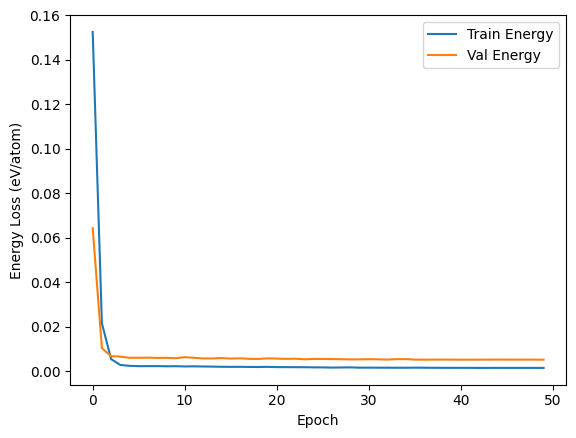

In [65]:
import matplotlib.pyplot as plt

history = trainer.training_history

plt.plot(history['e']['train'], label="Train Energy")
plt.plot(history['e']['val'], label="Val Energy")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Energy Loss (eV/atom)")
plt.show()

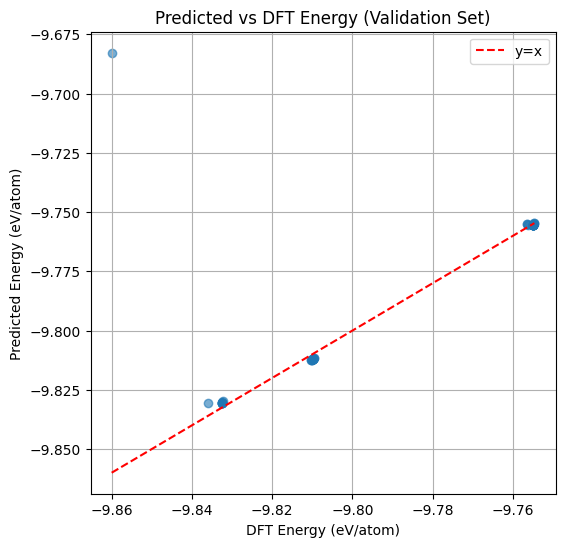

In [68]:
import matplotlib.pyplot as plt
import torch

preds = []
true_vals = []

# Use the validation loader from training
for graphs, targets in val_loader:
    with torch.no_grad():
        # graphs is a list of CrystalGraph objects
        # model returns a dictionary with energy predictions
        batch_output = model(graphs)
        
        # Extract energy from output dictionary
        if isinstance(batch_output, dict):
            batch_pred = batch_output.get('e', batch_output.get('energy'))
        else:
            batch_pred = batch_output
        
        # Convert to numpy and extend lists
        if hasattr(batch_pred, 'cpu'):
            preds.extend(batch_pred.cpu().numpy())
        else:
            preds.extend(batch_pred)
        
        true_vals.extend(targets['e'].cpu().numpy())

plt.figure(figsize=(6, 6))
plt.scatter(true_vals, preds, alpha=0.6)
plt.plot([min(true_vals), max(true_vals)], [min(true_vals), max(true_vals)], 'r--', label='y=x')
plt.xlabel('DFT Energy (eV/atom)')
plt.ylabel('Predicted Energy (eV/atom)')
plt.title('Predicted vs DFT Energy (Validation Set)')
plt.legend()
plt.grid(True)
plt.show()
